In [19]:
import os
import cv2
import csv
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from torch.optim.lr_scheduler import StepLR
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from scipy.stats import pearsonr
import zipfile

In [20]:

# =================== CONFIGURATION ===================

DATASET_DIR    = "dataset2"
LABELS_CSV     = os.path.join(DATASET_DIR, "labels.csv")
META_CSV       = os.path.join(DATASET_DIR, "scene_metadata.csv")
NPZ_DIR = os.path.join(DATASET_DIR, "npz_samples")
IMG_SIZE       = 64          # Downsample from 512 to 64 resolution
NUM_FRAMES     = 20          # Numboer of Frames per sample
LATENT_DIM     = 256
BATCH_SIZE     = 16
NUM_EPOCHS     = 40
LEARNING_RATE  = 1e-3         # Learning Rate
LAMBDA_VEL     = 0.5          # Weight for velocity losses
LAMBDA_PHYS    = 0.3          # Weight for physics consistency loss
TRAIN_SPLIT    = 0.8          # 80% train, 20% test
DEVICE         = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {DEVICE}")


Using device: cuda


In [21]:
import zipfile
import os

zip_file_path = '/content/dataset_final.zip'
extract_dir = '/content'

# Create the extraction directory if it doesn't exist
os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"'{zip_file_path}' extracted to '{extract_dir}'")

'/content/dataset_final.zip' extracted to '/content'


In [22]:
"""
    Loads MP4 videos from dataset2/samples/ and labels from labels.csv.

    Each sample returns:
        frames         — tensor of shape (NUM_FRAMES, 3, IMG_SIZE, IMG_SIZE), float32, normalized
        cor_label      — scalar tensor, float32
        vel_a_final    — scalar tensor, float32
        vel_b_final    — scalar tensor, float32
        vel_a_initial  — scalar tensor, float32 (from metadata, needed for consistency loss)
        vel_b_initial  — scalar tensor, float32 (from metadata, needed for consistency loss)
        sample_id      — string (for analysis)
"""

class CoRDataset(Dataset):
    def __init__(self, dataset_dir, labels_csv, meta_csv):
        self.dataset_dir = dataset_dir

        # Load labels — sample_id, restitution, final_vel_ax, final_vel_bx
        self.labels = []
        with open(labels_csv, "r") as f:
            reader = csv.DictReader(f)
            for row in reader:
                self.labels.append({
                    "sample_id":   row["sample_id"],
                    "restitution": float(row["restitution"]),
                    "vel_a_final": float(row["final_vel_ax"]),
                    "vel_b_final": float(row["final_vel_bx"]),
                })

        # Load initial velocities from metadata — needed for physics consistency loss
        self.meta = {}
        with open(meta_csv, "r") as f:
            reader = csv.DictReader(f)
            for row in reader:
                self.meta[row["sample_id"]] = {
                    "vel_a_initial": float(row["initial_vel_ax"]),
                    "vel_b_initial": float(row["initial_vel_bx"]),
                }

        self.transform = transforms.Compose([
          transforms.ToTensor(),                        # (H,W,C) uint8 → (C,H,W) float [0,1]
          transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225]),
        ])

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = self.labels[idx]
        sample_id = item["sample_id"]

        # Load video frames from MP4
        video_path = os.path.join(self.dataset_dir, "samples", f"{sample_id}.mp4")
        frames = self._load_npz(sample_id)

        # Retrieve initial velocities for physics consistency loss
        meta = self.meta.get(sample_id, {"vel_a_initial": 0.0, "vel_b_initial": 0.0})

        return {
            "frames":        frames,
            "cor":           torch.tensor(item["restitution"], dtype=torch.float32),
            "vel_a_final":   torch.tensor(item["vel_a_final"], dtype=torch.float32),
            "vel_b_final":   torch.tensor(item["vel_b_final"], dtype=torch.float32),
            "vel_a_initial": torch.tensor(meta["vel_a_initial"], dtype=torch.float32),
            "vel_b_initial": torch.tensor(meta["vel_b_initial"], dtype=torch.float32),
            "sample_id":     sample_id,
        }


    def _load_npz(self, sample_id):
      npz_path = os.path.join(NPZ_DIR, f"{sample_id}.npz")
      data = np.load(npz_path)
      frames = data["frames"]  # (20, 64, 64, 3) uint8

      # Apply transform to each frame
      frame_tensors = [self.transform(frames[i]) for i in range(len(frames))]
      return torch.stack(frame_tensors)  # (20, 3, 64, 64)

In [23]:
# =================== MODEL ===================

class FrameCNN(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()

        self.conv_blocks = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        # Collapse spatial dimensions to fixed size regardless of input resolution
        self.pool = nn.AdaptiveAvgPool2d((4, 4))    # 16×16 → 4×4, 128 channels → 128×16=2048

        self.fc = nn.Sequential(
            nn.Flatten(),                           # 128 × 4 × 4 = 2048
            nn.Linear(128 * 4 * 4, latent_dim),
            nn.ReLU(),
        )

    def forward(self, x):
        # x: (batch, 3, H, W)
        x = self.conv_blocks(x)
        x = self.pool(x)
        x = self.fc(x)
        return x


In [24]:
# =================== CNN + TRANSFORMER ENCODER ===================

class CNNTransformerEncoder(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM, num_frames=NUM_FRAMES,
                 nhead=8, num_layers=3, dim_feedforward=512, dropout=0.1):
        super().__init__()

        self.latent_dim = latent_dim
        self.num_frames = num_frames

        # Shared spatial encoder — identical to Architecture 1
        self.cnn = FrameCNN(latent_dim)

        # Learnable CLS token — one vector, broadcast across batch during forward
        # This is the "summary token" that aggregates information from all frames
        self.cls_token = nn.Parameter(torch.randn(1, 1, latent_dim))

        # Learned positional encoding — num_frames + 1 positions (CLS + 20 frames)
        self.pos_encoding = LearnedPositionalEncoding(
            max_len=num_frames, latent_dim=latent_dim
        )

        # Transformer encoder
        # batch_first=True means input shape is (batch, seq, dim) — more intuitive
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=latent_dim,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
            norm_first=True,    # Pre-norm (LayerNorm before attention) — more stable training
                                # than post-norm, especially with small datasets
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers,
            norm=nn.LayerNorm(latent_dim)   # Final layer norm
        )

        # Small projection after CLS extraction
        # Aligns Transformer output dimension with the head input expectations
        self.output_proj = nn.Sequential(
            nn.Linear(latent_dim, latent_dim),
            nn.ReLU(),
        )

    def forward(self, x):
        # x: (batch, num_frames, 3, H, W)
        batch, num_frames, C, H, W = x.shape

        # ---- Step 1: Apply CNN to all frames ----
        # Flatten batch and time dims to process all frames in one CNN forward pass
        x = x.view(batch * num_frames, C, H, W)    # (batch×num_frames, 3, H, W)
        x = self.cnn(x)                             # (batch×num_frames, latent_dim)

        # Reshape back to sequence format
        x = x.view(batch, num_frames, self.latent_dim)  # (batch, num_frames, latent_dim)

        # ---- Step 2: Prepend CLS token ----
        # cls_token shape: (1, 1, latent_dim) → expand to (batch, 1, latent_dim)
        cls = self.cls_token.expand(batch, -1, -1)  # (batch, 1, latent_dim)
        x = torch.cat([cls, x], dim=1)              # (batch, num_frames+1, latent_dim)

        # ---- Step 3: Add positional encoding ----
        # Positions: 0=CLS, 1=frame_0, 2=frame_1, ..., 20=frame_19
        x = self.pos_encoding(x)                    # (batch, num_frames+1, latent_dim)

        # ---- Step 4: Transformer self-attention ----
        # Every token (including CLS) attends to every other token
        x = self.transformer(x)                     # (batch, num_frames+1, latent_dim)

        # ---- Step 5: Extract CLS token as latent vector ----
        # CLS token is at position 0
        cls_output = x[:, 0, :]                     # (batch, latent_dim)

        # ---- Step 6: Final projection ----
        latent = self.output_proj(cls_output)        # (batch, latent_dim)
        return latent


In [25]:
# =================== POSITIONAL ENCODING ===================

class LearnedPositionalEncoding(nn.Module):
    def __init__(self, max_len, latent_dim):
        super().__init__()
        # Embedding table: one learnable vector per sequence position
        # max_len + 1 because we prepend a CLS token (position 0)
        self.pos_embedding = nn.Embedding(max_len + 1, latent_dim)

    def forward(self, x):
        # x: (batch, seq_len, latent_dim)
        batch, seq_len, _ = x.shape

        # Create position indices [0, 1, 2, ..., seq_len-1]
        positions = torch.arange(seq_len, device=x.device).unsqueeze(0)  # (1, seq_len)
        positions = positions.expand(batch, -1)                           # (batch, seq_len)

        # Add positional embeddings to frame features
        x = x + self.pos_embedding(positions)
        return x

In [26]:
class CoRPredictor(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        self.encoder = CNNTransformerEncoder(latent_dim)

        # CoR head — output bounded to [0, 1] via sigmoid
        self.cor_head = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

        # Velocity heads — signed floats, no activation
        self.vel_a_head = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

        self.vel_b_head = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        # x: (batch, num_frames, 3, H, W)
        latent = self.encoder(x)                        # (batch, latent_dim)

        cor_pred   = self.cor_head(latent).squeeze(-1).clamp(0.0,1.0)
        vel_a_pred = self.vel_a_head(latent).squeeze(-1)
        vel_b_pred = self.vel_b_head(latent).squeeze(-1)

        return cor_pred, vel_a_pred, vel_b_pred, latent


In [27]:
# =================== LOSS FUNCTION ===================

def compute_loss(cor_pred, vel_a_pred, vel_b_pred,
                 cor_true, vel_a_true, vel_b_true,
                 vel_a_initial, vel_b_initial):
    mse = nn.MSELoss()

    # Primary losses
    loss_cor   = mse(cor_pred, cor_true)
    loss_vel_a = mse(vel_a_pred, vel_a_true)
    loss_vel_b = mse(vel_b_pred, vel_b_true)

    # Physics consistency loss
    rel_speed_before = torch.abs(vel_a_initial - vel_b_initial) + 1e-8

    # CoR implied by the predicted velocities
    rel_speed_after  = torch.abs(vel_b_pred - vel_a_pred)
    cor_from_vel     = rel_speed_after / rel_speed_before

    # Penalize disagreement between cor_pred and what the velocity predictions imply
    loss_consistency = mse(cor_from_vel, cor_pred)

    total = (loss_cor
             + LAMBDA_VEL  * loss_vel_a
             + LAMBDA_VEL  * loss_vel_b
             + LAMBDA_PHYS * loss_consistency)

    return total, loss_cor, loss_vel_a, loss_vel_b, loss_consistency


In [28]:
# =================== TRAINING LOOP ===================

def train_one_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0.0
    total_cor_loss = 0.0

    for i, batch in enumerate(loader):

        if i%50 == 0:
          print(f"  batch {i}/{len(loader)}", end="\r")

        frames       = batch["frames"].to(device)           # (B, 120, 3, 128, 128)
        cor_true     = batch["cor"].to(device)
        vel_a_true   = batch["vel_a_final"].to(device)
        vel_b_true   = batch["vel_b_final"].to(device)
        vel_a_init   = batch["vel_a_initial"].to(device)
        vel_b_init   = batch["vel_b_initial"].to(device)

        optimizer.zero_grad()

        cor_pred, vel_a_pred, vel_b_pred, _ = model(frames)

        loss, l_cor, l_va, l_vb, l_phys = compute_loss(
            cor_pred, vel_a_pred, vel_b_pred,
            cor_true, vel_a_true, vel_b_true,
            vel_a_init, vel_b_init
        )

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # gradient clipping
        optimizer.step()

        total_loss     += loss.item()
        total_cor_loss += l_cor.item()

    n = len(loader)
    return total_loss / n, total_cor_loss / n


In [29]:
@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    total_loss = 0.0
    all_cor_pred  = []
    all_cor_true  = []
    all_latents   = []
    all_ids       = []

    for batch in loader:
        frames       = batch["frames"].to(device)
        cor_true     = batch["cor"].to(device)
        vel_a_true   = batch["vel_a_final"].to(device)
        vel_b_true   = batch["vel_b_final"].to(device)
        vel_a_init   = batch["vel_a_initial"].to(device)
        vel_b_init   = batch["vel_b_initial"].to(device)

        cor_pred, vel_a_pred, vel_b_pred, latent = model(frames)

        loss, _, _, _, _ = compute_loss(
            cor_pred, vel_a_pred, vel_b_pred,
            cor_true, vel_a_true, vel_b_true,
            vel_a_init, vel_b_init
        )

        total_loss    += loss.item()
        all_cor_pred.append(cor_pred.cpu())
        all_cor_true.append(cor_true.cpu())
        all_latents.append(latent.cpu())
        all_ids.extend(batch["sample_id"])

    all_cor_pred = torch.cat(all_cor_pred)
    all_cor_true = torch.cat(all_cor_true)
    all_latents  = torch.cat(all_latents)   # (N, latent_dim)

    mae = torch.mean(torch.abs(all_cor_pred - all_cor_true)).item()

    ss_res = torch.sum((all_cor_true - all_cor_pred) ** 2).item()
    ss_tot = torch.sum((all_cor_true - all_cor_true.mean()) ** 2).item()
    r2     = 1 - ss_res / (ss_tot + 1e-8)

    n = len(loader)
    return total_loss / n, mae, r2, all_latents.numpy(), all_cor_true.numpy(), all_ids


In [34]:
# =================== LATENT SPACE ANALYSIS ===================

def plot_tsne(latents, cor_labels, title="t-SNE of Latent Space — Architecture 1"):
    print("Running t-SNE...")
    tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
    proj = tsne.fit_transform(latents)

    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(proj[:, 0], proj[:, 1],
                          c=cor_labels, cmap="RdYlBu_r",
                          alpha=0.7, s=15)
    plt.colorbar(scatter, label="Coefficient of Restitution")
    plt.title(title)
    plt.xlabel("t-SNE dim 1")
    plt.ylabel("t-SNE dim 2")
    plt.tight_layout()
    plt.savefig("tsne_arch1.png", dpi=150)
    plt.show()
    print("Saved: tsne_arch1.png")

In [31]:
def plot_prediction_vs_true(cor_pred_all, cor_true_all):
    plt.figure(figsize=(8, 8))
    plt.scatter(cor_true_all, cor_pred_all, alpha=0.3, s=10, color="steelblue")
    plt.plot([0, 1], [0, 1], "r--", linewidth=2, label="Perfect prediction")
    plt.xlabel("True CoR")
    plt.ylabel("Predicted CoR")
    plt.title("Predicted vs True Coefficient of Restitution")
    plt.legend()
    plt.tight_layout()
    plt.savefig("pred_vs_true_arch1.png", dpi=150)
    plt.show()
    print("Saved: pred_vs_true_arch1.png")


In [36]:
# =============================================================
# DEMONSTRATION 1 — LATENT SPACE INTERPOLATION
# =============================================================

def find_extreme_samples(model, test_loader, device, n_per_extreme=10):
    model.eval()

    low_latents   = []   # CoR = 0.0
    high_latents  = []   # CoR = 1.0
    low_vel_inits = []
    high_vel_inits = []

    with torch.no_grad():
        for batch in test_loader:
            frames       = batch["frames"].to(device)
            cor_true     = batch["cor"]
            vel_a_init   = batch["vel_a_initial"]
            vel_b_init   = batch["vel_b_initial"]

            _, _, _, latents = model(frames)
            latents = latents.cpu()

            for i in range(len(cor_true)):
                cor_val = cor_true[i].item()

                if abs(cor_val - 0.0) < 0.01 and len(low_latents) < n_per_extreme:
                    low_latents.append(latents[i])
                    low_vel_inits.append((vel_a_init[i].item(), vel_b_init[i].item()))

                if abs(cor_val - 1.0) < 0.01 and len(high_latents) < n_per_extreme:
                    high_latents.append(latents[i])
                    high_vel_inits.append((vel_a_init[i].item(), vel_b_init[i].item()))

            if len(low_latents) >= n_per_extreme and len(high_latents) >= n_per_extreme:
                break

    latent_low  = torch.stack(low_latents).mean(dim=0)   # (latent_dim,)
    latent_high = torch.stack(high_latents).mean(dim=0)  # (latent_dim,)

    # Use median initial velocities as representative values
    vel_a_init_rep = np.median([v[0] for v in low_vel_inits])
    vel_b_init_rep = np.median([v[1] for v in low_vel_inits])

    print(f"Found {len(low_latents)} CoR=0.0 samples and {len(high_latents)} CoR=1.0 samples")
    return latent_low, latent_high, vel_a_init_rep, vel_b_init_rep


def interpolate_latent_space(model, test_loader, device, n_steps=11):
    print("\n--- Demonstration 1: Latent Space Interpolation ---")

    latent_low, latent_high, vel_a_init, vel_b_init = find_extreme_samples(
        model, test_loader, device
    )

    latent_low  = latent_low.to(device)
    latent_high = latent_high.to(device)

    alphas       = np.linspace(0, 1, n_steps)
    cor_preds    = []
    vel_a_preds  = []
    vel_b_preds  = []
    implied_cors = []

    model.eval()
    with torch.no_grad():
        for alpha in alphas:
            # Linear interpolation in latent space
            # alpha=0.0 → pure low-CoR representation
            # alpha=1.0 → pure high-CoR representation
            latent_interp = (1 - alpha) * latent_low + alpha * latent_high
            latent_interp = latent_interp.unsqueeze(0)  # (1, latent_dim)

            # Decode from heads directly (bypass encoder — we already have latent)
            cor_pred   = model.cor_head(latent_interp).squeeze().item()
            vel_a_pred = model.vel_a_head(latent_interp).squeeze().item()
            vel_b_pred = model.vel_b_head(latent_interp).squeeze().item()

            # Physics consistency check
            # CoR = |relative velocity after| / |relative velocity before|
            rel_before  = abs(vel_a_init - vel_b_init) + 1e-8
            rel_after   = abs(vel_b_pred - vel_a_pred)
            implied_cor = rel_after / rel_before

            cor_preds.append(cor_pred)
            vel_a_preds.append(vel_a_pred)
            vel_b_preds.append(vel_b_pred)
            implied_cors.append(implied_cor)

    return alphas, cor_preds, vel_a_preds, vel_b_preds, implied_cors


def plot_interpolation(alphas, cor_preds, vel_a_preds, vel_b_preds,
                       implied_cors, save_path="interpolation_arch1.png"):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5)) # Adjusted figsize for better spacing

    # ---- Plot 1: CoR along interpolation path ----
    ax = axes[0]
    ax.plot(alphas, cor_preds, "o-", color="steelblue",
            linewidth=2.5, markersize=8, label="Predicted CoR")
    ax.plot(alphas, alphas, "r--", linewidth=1.5,
            label="Perfect linear interpolation")
    ax.set_xlabel("Interpolation α\n(0 = CoR=0.0 end, 1 = CoR=1.0 end)", fontsize=11)
    ax.set_ylabel("Predicted CoR", fontsize=11)
    ax.set_title("CoR Prediction Along\nLatent Space Interpolation", fontsize=12)
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.legend()
    ax.grid(True, alpha=0.3)

    # ---- Plot 2: Predicted Velocities ----
    ax = axes[1]
    ax.plot(alphas, vel_a_preds, "o-", color="green",
            linewidth=2.5, markersize=8, label="Predicted Vel A")
    ax.plot(alphas, vel_b_preds, "o-", color="orange",
            linewidth=2.5, markersize=8, label="Predicted Vel B")
    ax.set_xlabel("Interpolation α", fontsize=11)
    ax.set_ylabel("Predicted Velocity", fontsize=11)
    ax.set_title("Predicted Velocities Along\nLatent Space Interpolation", fontsize=12)
    ax.legend()
    ax.grid(True, alpha=0.3)

    # ---- Plot 3: Implied CoR vs. Predicted CoR ----
    ax = axes[2]
    ax.plot(alphas, implied_cors, "o-", color="purple",
            linewidth=2.5, markersize=8, label="Implied CoR from Vel")
    ax.plot(alphas, cor_preds, "x--", color="steelblue",
            linewidth=1.5, markersize=8, label="Directly Predicted CoR")
    ax.set_xlabel("Interpolation α", fontsize=11)
    ax.set_ylabel("CoR Value", fontsize=11)
    ax.set_title("Implied vs. Predicted CoR", fontsize=12)
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"Saved: {save_path}")


def run_all_demonstrations(model, test_loader, device,
                           latents_all, cor_labels_all):

    print("\n" + "="*60)
    print("PHYSICS UNDERSTANDING DEMONSTRATIONS")
    print("="*60)

    # ---- Demonstration 1: Latent Space Interpolation ----
    alphas, cor_preds, vel_a_preds, vel_b_preds, implied_cors = \
        interpolate_latent_space(model, test_loader, device, n_steps=11)

    plot_interpolation(
        alphas, cor_preds, vel_a_preds, vel_b_preds, implied_cors,
        save_path="demo1_interpolation_arch1.png"
    )
    print("\n" + "="*60)

Loading dataset...
Total samples: 3300
Train: 2640 | Test: 660


/tmp/ipykernel_1703/3659569919.py:34: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(


Architecture 1 — CNN + LSTM
Trainable parameters: 2,321,027

Training for 40 epochs...
Epoch   1/40 | Train Loss: 2396.3285 | CoR Loss: 0.0621 | Test MAE: 0.1228 | Test R²: 0.7737 | LR: 1.00e-03
  ✓ Saved best model (MAE=0.1228)
Epoch   2/40 | Train Loss: 692.8287 | CoR Loss: 0.0141 | Test MAE: 0.0871 | Test R²: 0.8855 | LR: 1.00e-03
  ✓ Saved best model (MAE=0.0871)
Epoch   3/40 | Train Loss: 635.0761 | CoR Loss: 0.0122 | Test MAE: 0.0802 | Test R²: 0.8949 | LR: 1.00e-03
  ✓ Saved best model (MAE=0.0802)
Epoch   4/40 | Train Loss: 507.9900 | CoR Loss: 0.0154 | Test MAE: 0.1002 | Test R²: 0.8276 | LR: 1.00e-03
Epoch   5/40 | Train Loss: 171.7812 | CoR Loss: 0.0114 | Test MAE: 0.0713 | Test R²: 0.9251 | LR: 1.00e-03
  ✓ Saved best model (MAE=0.0713)
Epoch   6/40 | Train Loss: 86.2131 | CoR Loss: 0.0101 | Test MAE: 0.0612 | Test R²: 0.9406 | LR: 1.00e-03
  ✓ Saved best model (MAE=0.0612)
Epoch   7/40 | Train Loss: 63.3741 | CoR Loss: 0.0081 | Test MAE: 0.0526 | Test R²: 0.9563 | LR: 1.00

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


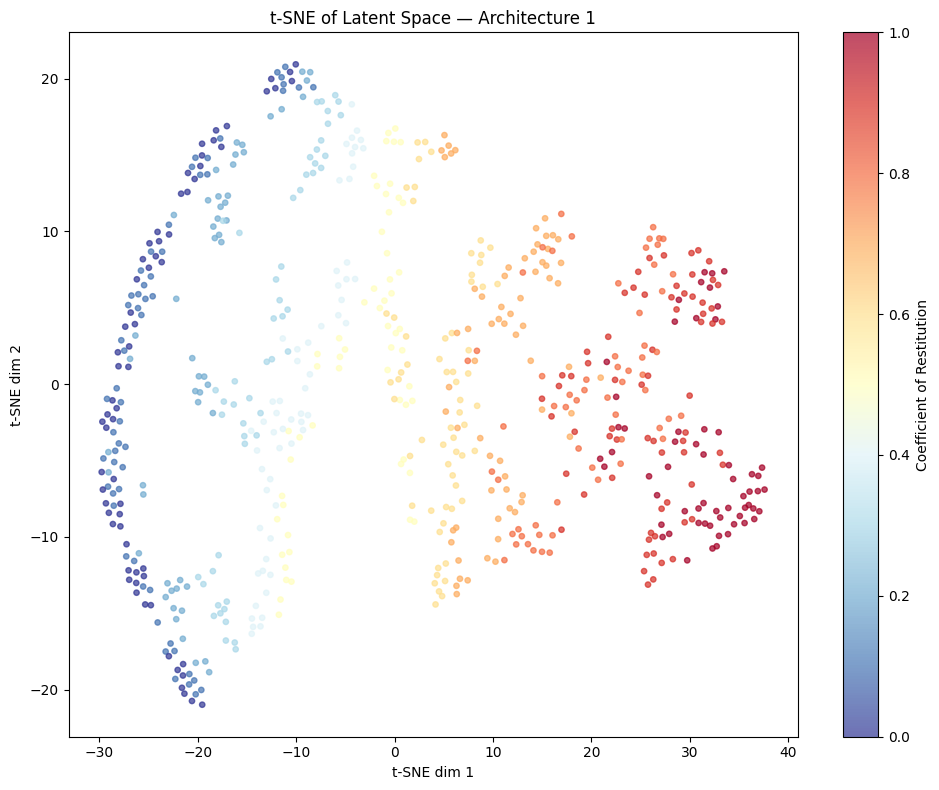

Saved: tsne_arch1.png


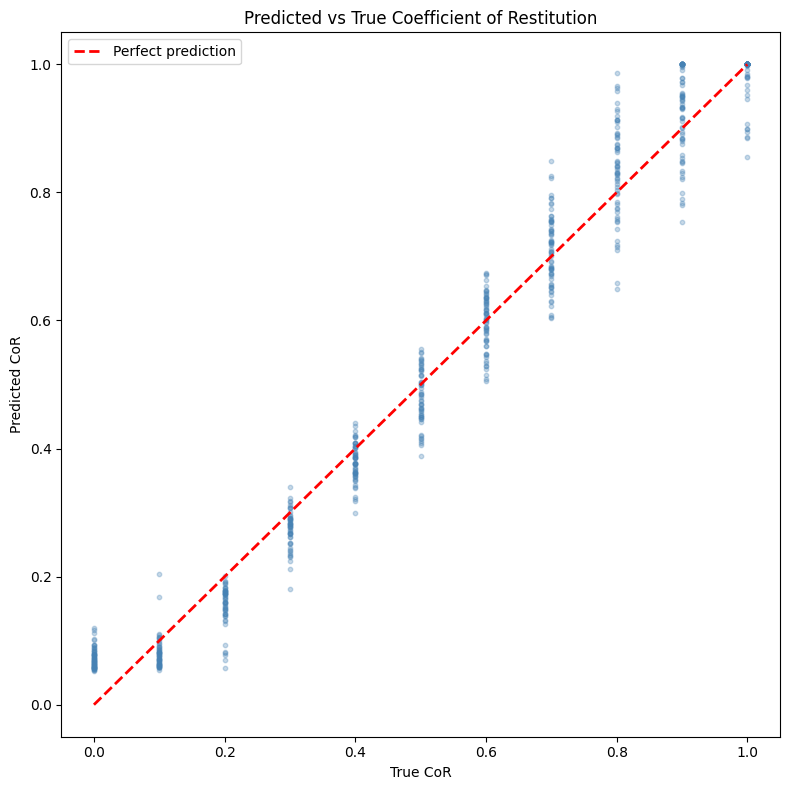

Saved: pred_vs_true_arch1.png


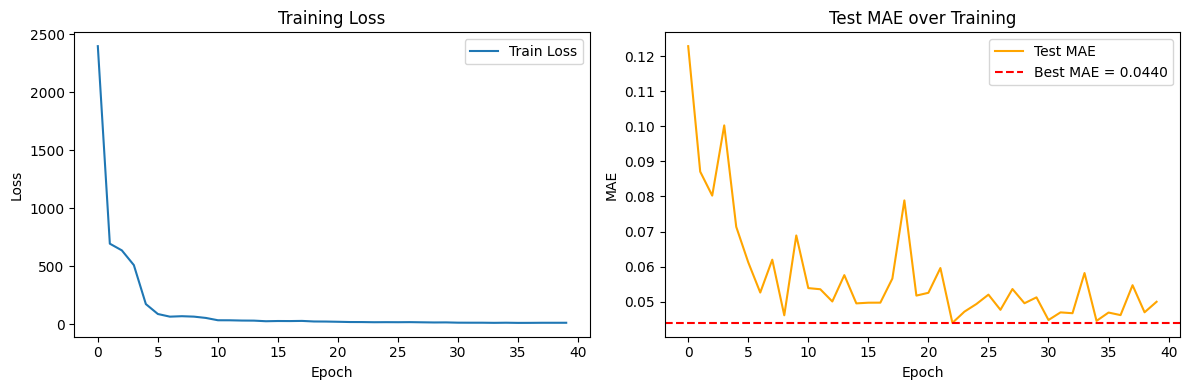

Saved: training_curves_arch1.png

Architecture 1 complete.
Best checkpoint saved to: best_arch1.pt

PHYSICS UNDERSTANDING DEMONSTRATIONS

--- Demonstration 1: Latent Space Interpolation ---
Found 10 CoR=0.0 samples and 10 CoR=1.0 samples


TypeError: 'Axes' object is not subscriptable

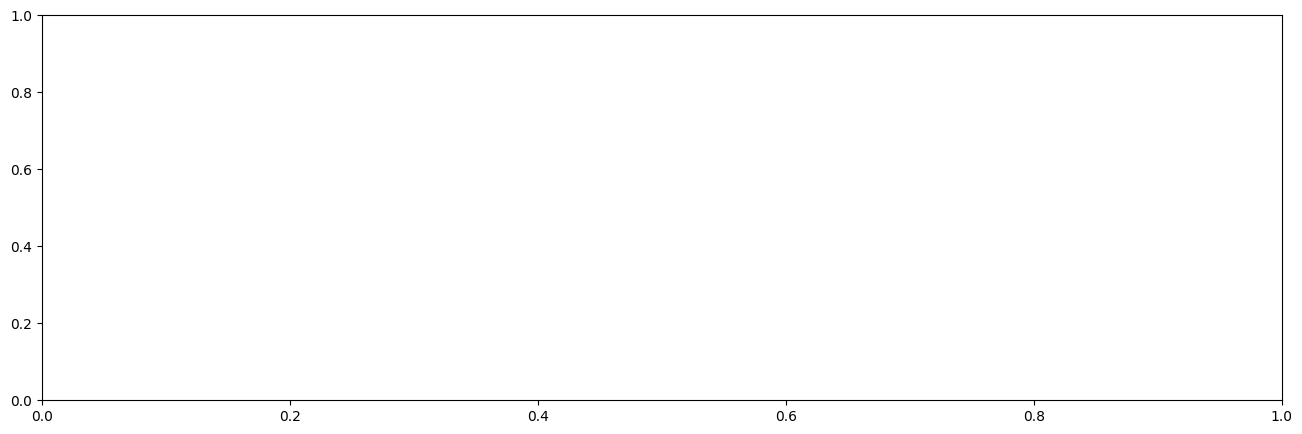

In [33]:
# =================== MAIN ===================
def main():
    # ---- Dataset ----
    print("Loading dataset...")
    dataset = CoRDataset(DATASET_DIR, LABELS_CSV, META_CSV)
    print(f"Total samples: {len(dataset)}")

    # Train/test split — deterministic seed for reproducibility
    n_train = int(len(dataset) * TRAIN_SPLIT)
    n_test  = len(dataset) - n_train
    train_set, test_set = random_split(
        dataset, [n_train, n_test],
        generator=torch.Generator().manual_seed(42)
    )
    print(f"Train: {n_train} | Test: {n_test}")

    train_loader = DataLoader(train_set, batch_size=BATCH_SIZE,
                              shuffle=True,  num_workers=2, pin_memory=True)
    test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE,
                              shuffle=False, num_workers=2, pin_memory=True)

    # ---- Model ----
    model = CoRPredictor(latent_dim=LATENT_DIM).to(DEVICE)
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Architecture 1 — CNN + Transformer")
    print(f"Trainable parameters: {total_params:,}")

    # ---- Optimizer + Scheduler ----
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
    # StepLR: halve learning rate every 10 epochs
    scheduler = StepLR(optimizer, step_size=10, gamma=0.5)

    # ---- Training ----
    print(f"\nTraining for {NUM_EPOCHS} epochs...")
    train_losses = []
    test_maes    = []
    best_mae     = float("inf")

    for epoch in range(1, NUM_EPOCHS + 1):
        train_loss, train_cor_loss = train_one_epoch(model, train_loader, optimizer, DEVICE)
        test_loss, mae, r2, _, _, _ = evaluate(model, test_loader, DEVICE)
        scheduler.step()

        train_losses.append(train_loss)
        test_maes.append(mae)

        print(f"Epoch {epoch:>3}/{NUM_EPOCHS} | "
              f"Train Loss: {train_loss:.4f} | "
              f"CoR Loss: {train_cor_loss:.4f} | "
              f"Test MAE: {mae:.4f} | "
              f"Test R²: {r2:.4f} | "
              f"LR: {scheduler.get_last_lr()[0]:.2e}")

        # Save best model checkpoint
        if mae < best_mae:
            best_mae = mae
            torch.save(model.state_dict(), "best_arch1.pt")
            print(f"  ✓ Saved best model (MAE={best_mae:.4f})")

    # ---- Load best model for analysis ----
    print(f"\nLoading best model (MAE={best_mae:.4f}) for analysis...")
    model.load_state_dict(torch.load("best_arch1.pt", map_location=DEVICE))

    # ---- Final evaluation ----
    test_loss, mae, r2, latents, cor_true, sample_ids = evaluate(
        model, test_loader, DEVICE
    )
    print(f"\nFinal Test Results:")
    print(f"  MAE  : {mae:.4f}  (mean absolute error on CoR — lower is better)")
    print(f"  R²   : {r2:.4f}  (variance explained — higher is better, max=1.0)")

    # ---- Get predictions for scatter plot ----
    # Re-run inference to get predictions alongside true values
    model.eval()
    cor_pred_all = []
    cor_true_all = []
    with torch.no_grad():
        for batch in test_loader:
            frames   = batch["frames"].to(DEVICE)
            cor_true_batch = batch["cor"]
            cor_pred_batch, _, _, _ = model(frames)
            cor_pred_all.append(cor_pred_batch.cpu().numpy())
            cor_true_all.append(cor_true_batch.numpy())

    cor_pred_all = np.concatenate(cor_pred_all)
    cor_true_all = np.concatenate(cor_true_all)

    # Latent space analysis
    plot_tsne(latents, cor_true)
    plot_prediction_vs_true(cor_pred_all, cor_true_all)

    # Training curves
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(train_losses, label="Train Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title("Training Loss")
    axes[0].legend()

    axes[1].plot(test_maes, label="Test MAE", color="orange")
    axes[1].axhline(best_mae, color="red", linestyle="--",
                    label=f"Best MAE = {best_mae:.4f}")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("MAE")
    axes[1].set_title("Test MAE over Training")
    axes[1].legend()

    plt.tight_layout()
    plt.savefig("training_curves_arch1.png", dpi=150)
    plt.show()
    print("Saved: training_curves_arch1.png")

    print("\nArchitecture 1 complete.")
    print(f"Best checkpoint saved to: best_arch1.pt")

    run_all_demonstrations(model, test_loader, DEVICE, latents, cor_true)


if __name__ == "__main__":
    main()

Loading dataset...
Total samples: 3300
Train: 2640 | Test: 660
Architecture 1 — CNN + Transformer
Trainable parameters: 2,321,027


/tmp/ipykernel_1703/3659569919.py:34: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(



Final Test Results:
  MAE  : 0.0440  (mean absolute error on CoR — lower is better)
  R²   : 0.9694  (variance explained — higher is better, max=1.0)
Running t-SNE...


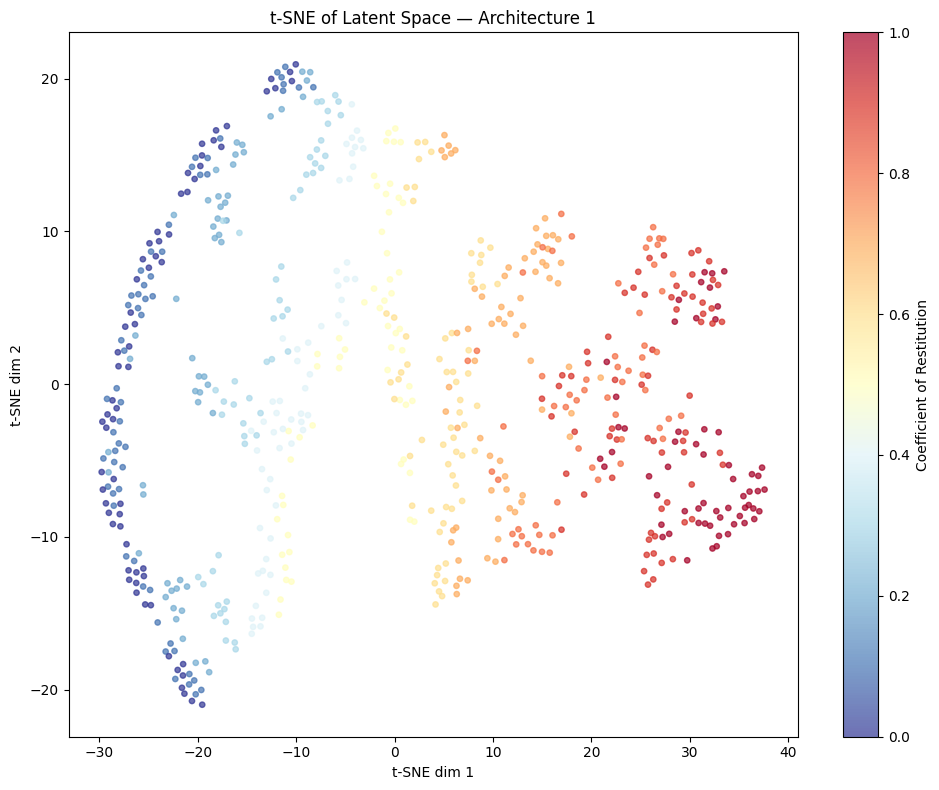

Saved: tsne_arch1.png


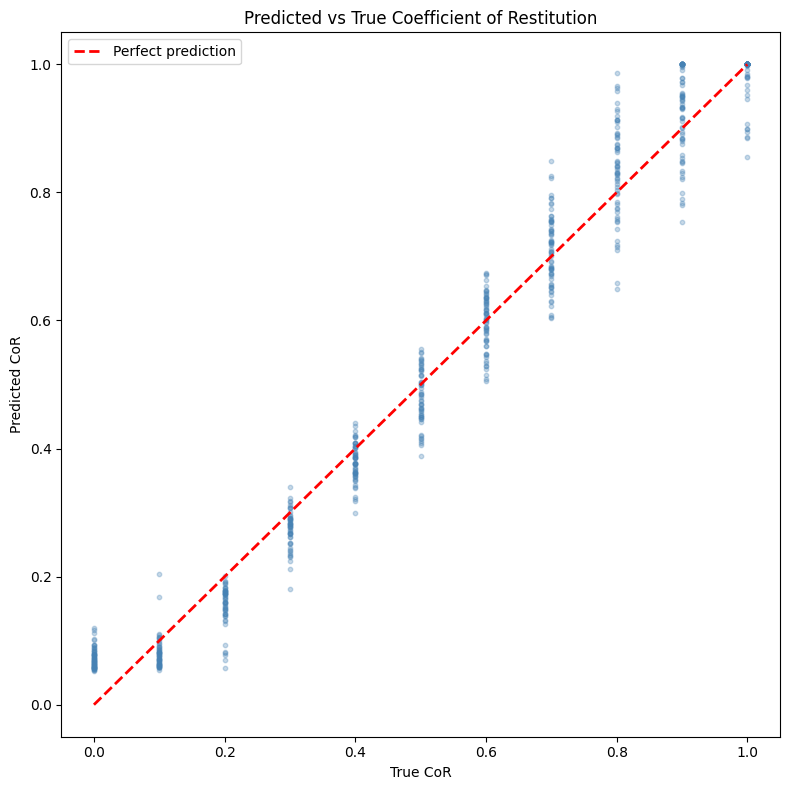

Saved: pred_vs_true_arch1.png

PHYSICS UNDERSTANDING DEMONSTRATIONS

--- Demonstration 1: Latent Space Interpolation ---
Found 10 CoR=0.0 samples and 10 CoR=1.0 samples


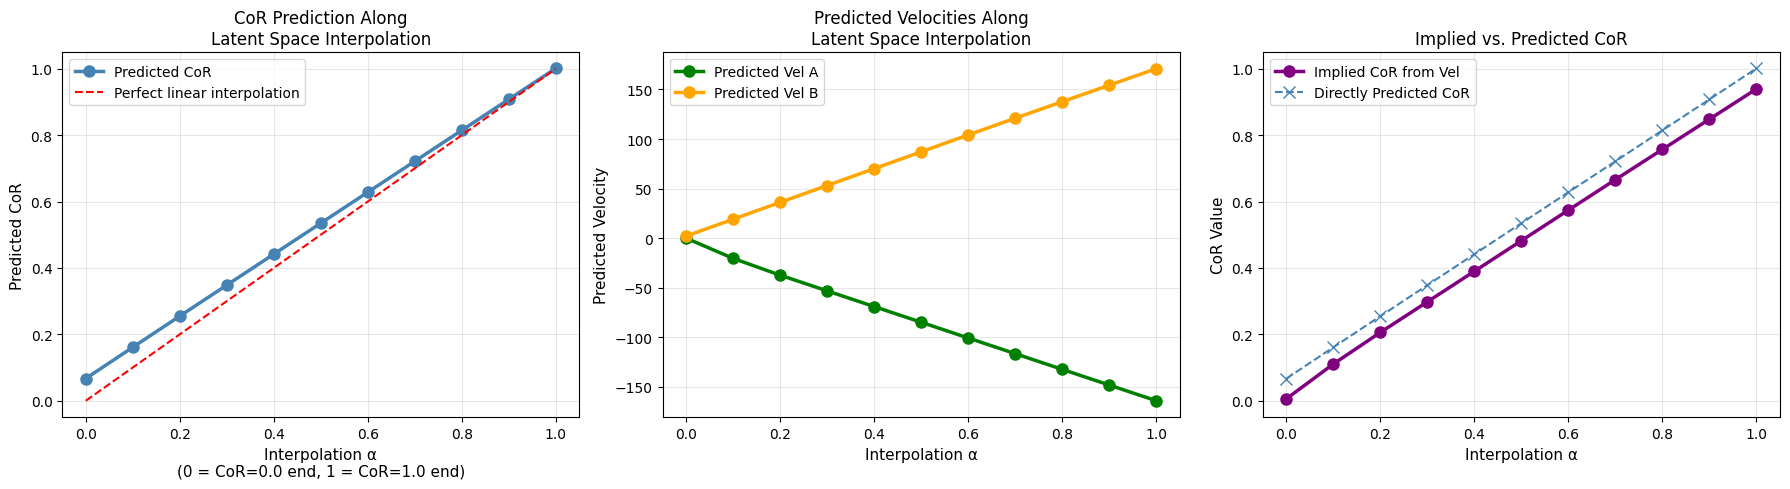

Saved: demo1_interpolation_arch1.png



In [37]:
# =================== MAIN ===================
def run():
    # ---- Dataset ----
    print("Loading dataset...")
    dataset = CoRDataset(DATASET_DIR, LABELS_CSV, META_CSV)
    print(f"Total samples: {len(dataset)}")

    # Train/test split — deterministic seed for reproducibility
    n_train = int(len(dataset) * TRAIN_SPLIT)
    n_test  = len(dataset) - n_train
    train_set, test_set = random_split(
        dataset, [n_train, n_test],
        generator=torch.Generator().manual_seed(42)
    )
    print(f"Train: {n_train} | Test: {n_test}")

    train_loader = DataLoader(train_set, batch_size=BATCH_SIZE,
                              shuffle=True,  num_workers=2, pin_memory=True)
    test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE,
                              shuffle=False, num_workers=2, pin_memory=True)

    # ---- Model ----
    model = CoRPredictor(latent_dim=LATENT_DIM).to(DEVICE)
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Architecture 1 — CNN + Transformer")
    print(f"Trainable parameters: {total_params:,}")

    model.load_state_dict(torch.load("best_arch1.pt", map_location=DEVICE))

    # ---- Final evaluation ----
    test_loss, mae, r2, latents, cor_true, sample_ids = evaluate(
        model, test_loader, DEVICE
    )
    print(f"\nFinal Test Results:")
    print(f"  MAE  : {mae:.4f}  (mean absolute error on CoR — lower is better)")
    print(f"  R²   : {r2:.4f}  (variance explained — higher is better, max=1.0)")

    # ---- Get predictions for scatter plot ----
    # Re-run inference to get predictions alongside true values
    model.eval()
    cor_pred_all = []
    cor_true_all = []
    with torch.no_grad():
        for batch in test_loader:
            frames   = batch["frames"].to(DEVICE)
            cor_true_batch = batch["cor"]
            cor_pred_batch, _, _, _ = model(frames)
            cor_pred_all.append(cor_pred_batch.cpu().numpy())
            cor_true_all.append(cor_true_batch.numpy())

    cor_pred_all = np.concatenate(cor_pred_all)
    cor_true_all = np.concatenate(cor_true_all)

    # Latent space analysis
    plot_tsne(latents, cor_true)
    plot_prediction_vs_true(cor_pred_all, cor_true_all)
    run_all_demonstrations(model, test_loader, DEVICE, latents, cor_true)


run()